In [11]:
# Installing necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# For this demo only — SaANN does not require scikit-learn.
from sklearn.datasets import load_diabetes 


# SaANN libraries
from saann.models import SequentialModel
from saann.processing import Scaling
from saann.processing import train_test_split
from saann.losses import MSE


In [ ]:
# Install scikit-learn in this notebook kernel if you need.
%pip install scikit-learn

In [13]:
# Load dataset
diabetes = load_diabetes()
X = np.array(diabetes.data)
y = np.array(diabetes.target)

In [14]:
# Preparing X_train, y_train, X_test, y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, split_test_percentage = 0.3)

In [15]:
# Initialize model
model = SequentialModel()

In [16]:
# Define layer specifications: (input_size, neurons, activation, initialization)
layer_info = [
    (X.shape[1], 10, "relu", "he"),
    (10, 1, "linear", "he")
]

Training for 1000 Epochs with learning rate: 0.001
Epoch    1/1000, Loss (MSE): 24413.92131
Epoch  100/1000, Loss (MSE): 3027.05727
Epoch  200/1000, Loss (MSE): 2993.12394
Epoch  300/1000, Loss (MSE): 2941.53898
Epoch  400/1000, Loss (MSE): 2958.97929
Epoch  500/1000, Loss (MSE): 2899.21662
Epoch  600/1000, Loss (MSE): 2833.30073
Epoch  700/1000, Loss (MSE): 2917.76566
Epoch  800/1000, Loss (MSE): 2830.59479
Epoch  900/1000, Loss (MSE): 2808.25959
Epoch 1000/1000, Loss (MSE): 2861.87047

Final MSE Loss on training data: 2776.11871


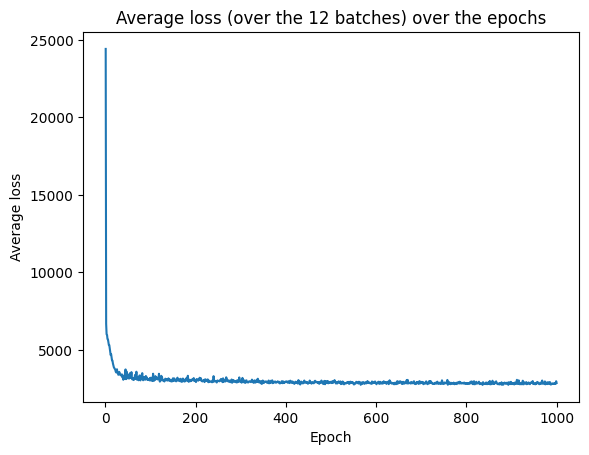

In [18]:
# Build and train
model.construct(layer_info, learning_rate=0.001)
final_pred = model.fit(X_train, y_train, epochs=1000, batch_size=26, graphical=True, real_time=False, log_plot=False)

In [19]:
# Make predictions
y_pred = model.predict(X_test)


Loss (MSE) on testing data: 2797.690162893907


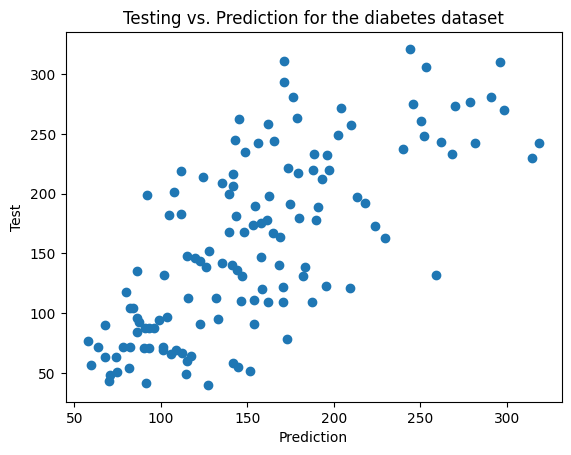

In [20]:
# Show prediction with MSE
mse = MSE(y_true=y_test, y_pred=y_pred)
print(f"\nLoss (MSE) on testing data: {mse}")
plt.scatter(x = y_pred, y = y_test)
plt.title("Testing vs. Prediction for the diabetes dataset")
plt.xlabel("Prediction")
plt.ylabel("Test")
plt.show()